In [1]:
# Firebase 데이터 조회 및 분석

import os
import json
import firebase_admin
from firebase_admin import credentials, firestore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import streamlit as st
import sys

# 프로젝트 루트(상위 디렉토리)를 sys.path에 추가해서 core 패키지 import 가능하게 설정
sys.path.append(os.path.abspath(".."))

# Firebase 초기화
def init_firebase():
    """Firebase 초기화"""
    try:
        if not firebase_admin._apps:
            
            if os.path.exists("../serviceAccountKey.json"):
                cred = credentials.Certificate("../serviceAccountKey.json")
                firebase_admin.initialize_app(cred)
                print("✅ Firebase: serviceAccountKey.json 인증 사용")
            else:
                print("❌ Firebase 인증 정보를 찾을 수 없습니다.")
                return None
        
        return firestore.client()
    
    except Exception as e:
        print(f"❌ Firebase 초기화 실패: {str(e)}")
        return None

# Firebase 클라이언트 초기화
db = init_firebase()

if db:
    print("\n📊 Firebase 데이터 조회 시작...\n")
    
    # 1. 모든 협상 결과 조회
    try:
        docs = db.collection("negotiation_results").stream()
        results = []
        for doc in docs:
            results.append(doc.to_dict())
        
        print(f"✅ 총 {len(results)}개의 협상 결과를 조회했습니다.\n")
        
        # 2. DataFrame으로 변환
        if results:
            data_list = []
            for result in results:
                data_list.append({
                    "session_id": result.get("session_id"),
                    "mode": result.get("mode"),
                    "human_role": result.get("human_role"),
                    "ai_role": result.get("ai_role"),
                    "model": result.get("model"),
                    "scenario": result.get("scenario"),
                    "buyer_points": result.get("buyer_points", 0),
                    "seller_points": result.get("seller_points", 0),
                    "timestamp": result.get("timestamp"),
                })
            
            df = pd.DataFrame(data_list)
            
            # 3. 데이터 요약
            print("═" * 60)
            print("📈 데이터 요약")
            print("═" * 60)
            print(f"총 행: {len(df)}")
            print(f"\n{'엑셀 같은 데이터 미리보기:'}\n")
            print(df.head(10).to_string())
            
            # 4. 기본 통계
            print(f"\n{'═' * 60}")
            print("📊 기본 통계")
            print("═" * 60)
            print(f"구매자 점수 평균: {df['buyer_points'].mean():.2f}")
            print(f"판매자 점수 평균: {df['seller_points'].mean():.2f}")
            print(f"구매자 점수 최고: {df['buyer_points'].max():.2f}")
            print(f"판매자 점수 최고: {df['seller_points'].max():.2f}")
            
            # 5. 모드별 분석
            print(f"\n{'═' * 60}")
            print("🎯 모드별 분석")
            print("═" * 60)
            mode_stats = df.groupby('mode')[['buyer_points', 'seller_points']].agg(['count', 'mean', 'std'])
            print(mode_stats.to_string())
            
            # 6. 모델별 분석
            print(f"\n{'═' * 60}")
            print("🤖 모델별 분석")
            print("═" * 60)
            model_stats = df.groupby('model')[['buyer_points', 'seller_points']].agg(['count', 'mean'])
            print(model_stats.to_string())
            
            # 7. 역할별 분석
            print(f"\n{'═' * 60}")
            print("👤 역할별 분석")
            print("═" * 60)
            role_stats = df.groupby('human_role')[['buyer_points', 'seller_points']].mean()
            print(role_stats.to_string())
            
            # 8. 시각화 준비 (나머지 셀에서 사용할 데이터)
            print(f"\n{'═' * 60}")
            print("✅ 분석 완료!")
            print("═" * 60)
            print(f"\n📌 다음 셀에서 사용할 수 있는 변수:")
            print("   - df: 모든 협상 데이터 (DataFrame)")
            print("   - results: 원본 데이터 (딕셔너리 리스트)")
    
    except Exception as e:
        print(f"❌ 데이터 조회 중 오류: {str(e)}")
else:
    print("❌ Firebase 초기화 실패")

✅ Firebase: serviceAccountKey.json 인증 사용

📊 Firebase 데이터 조회 시작...

✅ 총 8개의 협상 결과를 조회했습니다.

════════════════════════════════════════════════════════════
📈 데이터 요약
════════════════════════════════════════════════════════════
총 행: 8

엑셀 같은 데이터 미리보기:

                 session_id          mode human_role ai_role   model scenario  buyer_points  seller_points                        timestamp
0  348aae65_20260311_142322      baseline        판매자     구매자  gpt-4o     None           5.0           60.0 2026-03-11 14:23:23.454000+00:00
1  46d7b793_20260311_145412   cot_upgrade        판매자     구매자  gpt-4o     None          55.0           65.0 2026-03-11 14:54:13.584000+00:00
2  6d92672e_20260311_142441      baseline        판매자     구매자  gpt-4o     None          45.0           75.0 2026-03-11 14:24:41.840000+00:00
3  7509008a_20260311_144415  cot_previous        구매자     판매자  gpt-4o     None          55.0           55.0 2026-03-11 14:44:15.800000+00:00
4  89b33ec9_20260312_130149      baseline        구매자 

In [20]:
from core.scenarios import PRIORITIES
import itertools
from IPython.display import Image, display

def calculate_nash_point():
    """
    가능한 모든 협상 결과를 시뮬레이션하여
    1) 모든 가능한 점수 리스트 (파레토 구름용)
    2) Nash Point (최적 합의점)
    두 가지를 반환합니다.
    """
    buyer_goals = PRIORITIES["구매자"]
    seller_goals = PRIORITIES["판매자"]

    # 각 항목의 배점 가져오기
    b_refund = buyer_goals.get("환불 받기", 0)
    b_my_review = buyer_goals.get("판매자에 대한 부정적인 리뷰 유지하기", 0)
    b_your_review = buyer_goals.get("판매자가 나에 대한 부정적인 리뷰 철회하기", 0)
    b_apology = buyer_goals.get("상대로부터 공식적인 사과받기", 0)

    s_refund = seller_goals.get("환불 방어", 0)
    s_my_review = seller_goals.get("구매자에 대한 부정적인 리뷰 유지하기", 0) # 판매자가 쓴 리뷰 유지
    s_your_review = seller_goals.get("구매자가 나에 대한 부정적인 리뷰 철회하기", 0) # 구매자가 쓴 리뷰 철회
    s_apology = seller_goals.get("상대로부터 공식적인 사과받기", 0)

    all_outcomes = []
    max_product = -1
    nash_point = (0, 0)

    # 모든 경우의 수 순회 (3 x 2 x 2 x 2 x 2 = 48가지)
    # 환불 (1.0:전액, 0.5:부분, 0.0:없음)
    refund_opts = [1.0, 0.5, 0.0]
    # 구매자 리뷰 (1.0:철회, 0.0:유지)
    b_review_opts = [1.0, 0.0] 
    # 판매자 리뷰 (1.0:철회, 0.0:유지)
    s_review_opts = [1.0, 0.0]
    # 사과 (1.0: 안함, 0.0 함)
    b_apology_opts = [1.0, 0.0] 
    s_apology_opts = [1.0, 0.0]

    for rf, br, sr, ba, sa in itertools.product(refund_opts, b_review_opts, s_review_opts, b_apology_opts, s_apology_opts):
        b_score = (rf * b_refund) + ((1 - br) * b_my_review) + (sr * b_your_review) + (sa * b_apology)
        s_score = ((1 - rf) * s_refund) + ((1 - sr) * s_my_review) + (br * s_your_review) + (ba * s_apology)

        all_outcomes.append((b_score, s_score))
        # Nash Product (단, 점수가 0보다 작을 수 없다고 가정)
        product = b_score * s_score
        if product > max_product:
            max_product = product
            nash_point = (b_score, s_score)
            
    return all_outcomes, nash_point

def draw_pareto_plot(all_outcomes, nash_point, buyer_score=None, seller_score=None, session_id="all_samples"):
    """
    Draw a Pareto plot for negotiation outcomes.

    Parameters
    ----------
    all_outcomes : list[tuple(float, float)]
        All possible outcome points (buyer_score, seller_score).
    nash_point : tuple(float, float)
        Nash (ideal) point on the Pareto frontier.
    buyer_score : float, optional
        (Optional) current negotiation buyer score to highlight.
    seller_score : float, optional
        (Optional) current negotiation seller score to highlight.
    session_id : str, optional
        Used in the saved filename.

    Behavior
    --------
    - Background: all_outcomes (gray) and Pareto frontier (blue dashed line).
    - Nash point: gold star.
    - Firebase points: all samples from Firestore `negotiation_results`,
      colored by `mode` with small jitter to avoid overlap.
    - Optionally highlights a specific (buyer_score, seller_score) point in red.
    """
    save_dir = "images"
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    image_filename = f"Pareto_{session_id}.png"
    image_path = os.path.join(save_dir, image_filename)

    # NOTE: 주피터에서는 기본 inline backend를 사용해야 출력이 보입니다.
    # plt.switch_backend('Agg')  # <- 이 줄을 제거해서 출력 가능하게 수정

    plt.figure(figsize=(7, 7))

    # 1. All possible outcomes (background cloud)
    all_b = [p[0] for p in all_outcomes]
    all_s = [p[1] for p in all_outcomes]
    plt.scatter(all_b, all_s, color='gray', alpha=0.3, s=50, label='Possible Outcomes')

    # 2. Pareto frontier line
    sorted_points = sorted(all_outcomes, key=lambda x: x[0], reverse=True)
    frontier = []
    max_y = -1
    for x, y in sorted_points:
        if y > max_y:
            frontier.append((x, y))
            max_y = y
    fx = [p[0] for p in frontier]
    fy = [p[1] for p in frontier]
    plt.plot(fx, fy, color='blue', linestyle='--', linewidth=1.5, alpha=0.8, label='Pareto Frontier')
    
    # 3. Nash point
    nx, ny = nash_point
    plt.scatter(nx, ny, color='gold', marker='*', s=300, edgecolors='orange', zorder=10, label='Nash Point (Ideal)')
    plt.text(nx - 10, ny + 5, f"Nash\n({nx:.0f}, {ny:.0f})", fontsize=9, color='orange', fontweight='bold')

    # 4. Firebase negotiation samples (all sessions), colored by mode with jitter
    try:
        if 'db' in globals() and db is not None:
            docs = db.collection("negotiation_results").stream()
            buyer_list = []
            seller_list = []
            mode_list = []

            for doc in docs:
                d = doc.to_dict()
                b = d.get("buyer_points")
                s = d.get("seller_points")
                if b is None or s is None:
                    continue
                try:
                    b_val = float(b)
                    s_val = float(s)
                except (TypeError, ValueError):
                    continue
                buyer_list.append(b_val)
                seller_list.append(s_val)
                mode_list.append(d.get("mode", "Unknown"))

            if buyer_list:
                buyers = np.array(buyer_list, dtype=float)
                sellers = np.array(seller_list, dtype=float)

                # Jitter to avoid overplotting
                jitter_scale = 1.0
                buyers_j = buyers + np.random.normal(0, jitter_scale, size=len(buyers))
                sellers_j = sellers + np.random.normal(0, jitter_scale, size=len(sellers))

                unique_modes = sorted(set(mode_list))
                # Color map per mode
                base_colors = [
                    "tab:blue", "tab:orange", "tab:green", "tab:red",
                    "tab:purple", "tab:brown", "tab:pink", "tab:gray",
                    "tab:olive", "tab:cyan",
                ]
                color_map = {}
                for i, m in enumerate(unique_modes):
                    color_map[m] = base_colors[i % len(base_colors)]

                modes_arr = np.array(mode_list)

                for m in unique_modes:
                    mask = modes_arr == m
                    plt.scatter(
                        buyers_j[mask],
                        sellers_j[mask],
                        color=color_map[m],
                        alpha=0.7,
                        s=80,
                        label=f"Sample ({m})",
                        edgecolors='none',
                        zorder=4,
                    )
        else:
            print("⚠️ Firebase client 'db' is not available. Skipping sample points.")
    except Exception as e:
        print(f"⚠️ Error while fetching Firebase samples: {e}")

    # 5. Optional: highlight a specific current agreement point
    if buyer_score is not None and seller_score is not None:
        try:
            bx = float(buyer_score)
            sy = float(seller_score)
            plt.scatter(bx, sy, color='red', s=120, zorder=6, marker='X', label='Current Agreement')
            plt.text(bx + 2, sy + 2, f"({bx:.1f}, {sy:.1f})", fontsize=9, color='red')
        except (TypeError, ValueError):
            pass

    # 6. Style settings
    plt.xlim(-5, 105)
    plt.ylim(-5, 105)
    plt.xlabel("Buyer Score")
    plt.ylabel("Seller Score")
    plt.title(f"Negotiation Outcomes")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower left', fontsize=8, framealpha=0.9)

    # Save and display in notebook (works even with Agg backend)
    plt.savefig(image_path, dpi=100, bbox_inches="tight")
    display(Image(filename=image_path))
    plt.close()

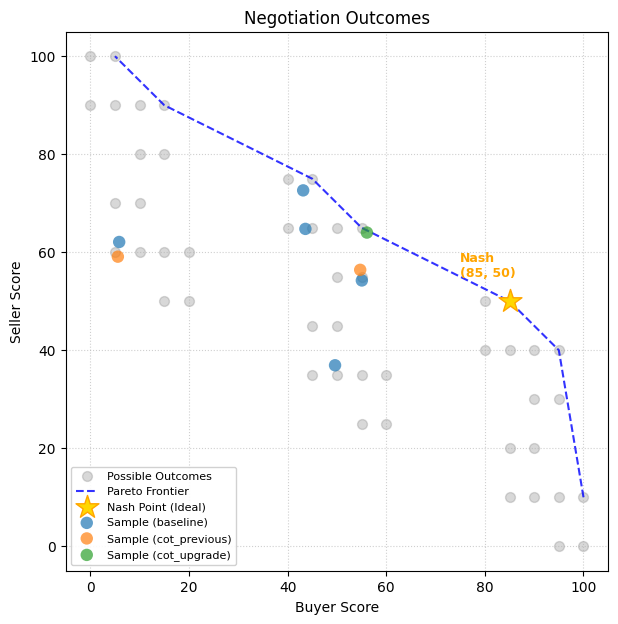

In [21]:
all_outcomes, nash_point = calculate_nash_point()
draw_pareto_plot(all_outcomes, nash_point)